In [1]:
import pandas as pd

df_category = pd.read_csv("../data/sales_by_category_state.csv")
df_category.head()

,customer_state,product_category,category_order_count,order_item_line_count,category_gmv,category_gmv_per_order
0,AC,sports_leisure,9,9,1677.46,186.384444
1,AC,watches_gifts,4,4,1389.60,347.400000
2,AC,health_beauty,6,7,1386.58,231.096667
3,AC,furniture_decor,7,12,1316.44,188.062857
4,AC,computers_accessories,6,8,1238.50,206.416667


In [2]:
df_category.shape

(1388, 6)

In [3]:
df_category.dtypes

customer_state                str
product_category              str
category_order_count        int64
order_item_line_count       int64
category_gmv              float64
category_gmv_per_order    float64
dtype: object

In [4]:
df_category.isnull().sum()

customer_state            0
product_category          0
category_order_count      0
order_item_line_count     0
category_gmv              0
category_gmv_per_order    0
dtype: int64

In [5]:
df_category.duplicated().sum()

np.int64(0)

In [6]:
df_category.describe().T

,count,mean,std,min,25%,50%,75%,max
category_order_count,1388.0,70.083573,268.113458,1.0,2.00,8.000000,33.000000,4347.00
order_item_line_count,1388.0,79.392651,308.366898,1.0,3.00,8.000000,37.000000,5157.00
category_gmv,1388.0,9525.575007,33185.958310,6.8,311.15,1309.380000,5764.947500,472238.07
category_gmv_per_order,1388.0,195.974273,246.016877,6.8,90.00,132.529687,200.784233,2919.40


In [7]:
df_category.groupby("customer_state")[[
    "category_order_count", 
    "order_item_line_count", 
    "category_gmv", 
    "category_gmv_per_order"
    ]].describe()

category_order_count                                            \
                              count        mean         std  min   25%    50%   
customer_state                                                                  
AC                             28.0    2.892857    2.096545  1.0   1.0    2.0   
AL                             43.0    9.232558   12.424701  1.0   1.0    4.0   
AM                             38.0    3.815789    3.797974  1.0   1.0    2.0   
AP                             21.0    3.190476    2.315579  1.0   2.0    2.0   
BA                             63.0   52.079365   76.126868  1.0   5.0   11.0   
CE                             53.0   24.283019   33.865331  1.0   2.0    7.0   
DF                             61.0   34.295082   51.515805  1.0   4.0    7.0   
ES                             59.0   34.016949   48.537398  1.0   3.0   10.0   
GO                             63.0   31.428571   48.101946  1.0   3.0    6.0   
MA                             47.0   15.340426   19.988341  1.0   1.0    5.0   
MG                             71.0  161.366197  263.265387  1.0  10.0   28.0   
MS                             55.0   12.800000   16.408444  1.0   1.5    4.0   
MT                             54.0   16.555556   21.269756  1.0   2.0    5.5   
PA                             52.0   18.288462   24.464730  1.0   1.0    4.5   
PB                             47.0   11.021277   14.379166  1.0   1.0    4.0   
PE                             57.0   28.052632   43.685737  1.0   3.0    6.0   
PI                             48.0    9.979167   11.997322  1.0   2.0    4.0   
PR                             65.0   76.353846  114.433309  1.0   7.0   14.0   
RJ                             71.0  175.633803  286.359626  1.0  10.5   40.0   
RN                             46.0   10.369565   12.438933  1.0   1.0    4.5   
RO                             42.0    5.833333    5.716543  1.0   1.0    4.5   
RR                             17.0    2.411765    1.543487  1.0   1.0    2.0   
RS                             68.0   79.514706  126.953922  1.0   5.0   17.0   
SC                             65.0   54.969231   82.567769  1.0   4.0   13.0   
SE                             42.0    8.000000    9.730515  1.0   1.0    3.0   
SP                             73.0  559.301370  943.379235  2.0  32.0  109.0   
TO                             39.0    7.051282    7.772924  1.0   1.0    3.0   

                               order_item_line_count              ...  \
                   75%     max                 count        mean  ...   
customer_state                                                    ...   
AC                4.00     9.0                  28.0    3.250000  ...   
AL               12.00    62.0                  43.0    9.930233  ...   
AM                4.75    15.0                  38.0    4.289474  ...   
AP                4.00    10.0                  21.0    3.857143  ...   
BA               71.50   319.0                  63.0   58.460317  ...   
CE               40.00   152.0                  53.0   26.905660  ...   
DF               43.00   219.0                  61.0   38.606557  ...   
ES               53.50   197.0                  59.0   37.711864  ...   
GO               43.00   206.0                  63.0   36.142857  ...   
MA               21.50    82.0                  47.0   17.021277  ...   
MG              198.50  1120.0                  71.0  181.915493  ...   
MS               20.00    60.0                  55.0   14.745455  ...   
MT               23.50    83.0                  54.0   19.203704  ...   
PA               27.50    99.0                  52.0   20.269231  ...   
PB               15.50    75.0                  47.0   12.468085  ...   
PE               41.00   220.0                  57.0   30.631579  ...   
PI               14.25    50.0                  48.0   10.895833  ...   
PR              107.00   420.0                  65.0   86.907692  ...   
RJ              191.00  1357.0                  71.

In [8]:
from IPython.display import display

for column in ["category_order_count", "order_item_line_count", "category_gmv", "category_gmv_per_order"]:
    max_index = df_category[column].idxmax()
    print(f"\n{column}")
    display(df_category.loc[max_index, ["customer_state", "product_category", column]])




category_order_count


customer_state                      SP
product_category        bed_bath_table
category_order_count              4347
Name: 1276, dtype: object


order_item_line_count


customer_state                       SP
product_category         bed_bath_table
order_item_line_count              5157
Name: 1276, dtype: object


category_gmv


customer_state                  SP
product_category    bed_bath_table
category_gmv             472238.07
Name: 1276, dtype: object


category_gmv_per_order


customer_state                                MT
product_category          signaling_and_security
category_gmv_per_order                    2919.4
Name: 620, dtype: object

In [9]:
weighted_average_category_order_value = (
    df_category["category_gmv"].sum() / df_category["category_order_count"].sum()
)

weighted_ave_order_item_line_count = (
    df_category["category_gmv"].sum() / df_category["order_item_line_count"].sum()
)

print(weighted_average_category_order_value)
print(weighted_ave_order_item_line_count)

135.91737026604713
119.98056308247955


In [10]:
df_product_category = (
    df_category
    .groupby("product_category", as_index=False)
    .agg(
        category_order_count=("category_order_count", "sum"),
        order_item_line_count=("order_item_line_count", "sum"),
        category_gmv=("category_gmv", "sum"),
        category_gmv_per_order=("category_gmv_per_order", "sum")
    )
)

df_product_category["average_order_value"] = (
    df_product_category["category_gmv"] / df_product_category["category_order_count"]
)

df_product_category["average_order_line_value"] = (
    df_product_category["category_gmv"] / df_product_category["order_item_line_count"]
)

df_product_category = df_product_category.sort_values(
    "category_gmv",
    ascending=False
).reset_index(drop=True)

display(df_product_category)

,product_category,category_order_count,order_item_line_count,category_gmv,category_gmv_per_order,average_order_value,average_order_line_value
0,health_beauty,8647,9465,1233131.72,4779.359464,142.608040,130.283330
1,watches_gifts,5495,5859,1166176.98,6250.292787,212.225110,199.040276
2,bed_bath_table,9272,10953,1023434.76,3480.452467,110.379072,93.438762
3,sports_leisure,7530,8431,954852.55,3992.154589,126.806448,113.254958
4,computers_accessories,6530,7644,888724.61,4339.976643,136.098715,116.264339
...,...,...,...,...,...,...,...
69,flowers,29,33,1110.04,334.588786,38.277241,33.637576
70,home_comfort_2,24,30,760.27,245.040455,31.677917,25.342333
71,cds_dvds_musicals,12,14,730.00,243.333333,60.833333,52.142857
72,fashion_childrens_clothes,7,7,519.95,309.972500,74.278571,74.278571


In [11]:
df_state = (
    df_category
    .groupby("customer_state", as_index=False)
    .agg(
        category_order_count=("category_order_count", "sum"),
        order_item_line_count=("order_item_line_count", "sum"),
        category_gmv=("category_gmv", "sum"),
        category_gmv_per_order=("category_gmv_per_order", "sum")
    )
)

df_state["average_order_value"] = (
    df_state["category_gmv"] / df_state["category_order_count"]
)

df_state["average_order_line_value"] = (
    df_state["category_gmv"] / df_state["order_item_line_count"]
)

df_state = df_state.sort_values(
    "category_gmv",
    ascending=False
).reset_index(drop=True)

display(df_state)

,customer_state,category_order_count,order_item_line_count,category_gmv,category_gmv_per_order,average_order_value,average_order_line_value
0,SP,40829,46448,5067633.16,10893.047905,124.118474,109.103366
1,RJ,12470,14143,1759651.13,11701.571113,141.110756,124.418520
2,MG,11457,12916,1552481.83,11926.883595,135.505091,120.198345
3,RS,5407,6134,728897.47,11616.945741,134.806264,118.829063
4,PR,4963,5649,666063.51,10855.128039,134.205825,117.908216
5,SC,3573,4097,507012.13,12026.237714,141.900960,123.752045
6,BA,3281,3683,493584.14,11184.105696,150.437105,134.016872
7,DF,2092,2355,296498.41,11158.429271,141.729641,125.901660
8,GO,1980,2277,282836.70,11706.161815,142.846818,124.214625
9,ES,2007,2225,268643.45,11489.073120,133.853239,120.738629


In [12]:
total_category_orders = df_state["category_order_count"].sum()
total_category_orders_line = df_state["order_item_line_count"].sum()
total_category_gmv = df_state["category_gmv"].sum()

df_state["order_share_pct"] = (
    df_state["category_order_count"] / total_category_orders * 100
)
df_state["order_line_pct"] = (
    df_state["order_item_line_count"] / total_category_orders_line * 100
)
df_state["gmv_share_pct"] = (
    df_state["category_gmv"] / total_category_gmv * 100
)

# GMVの大きい上位10州を表示する
display(
    df_state[
        [
            "customer_state",
            "category_order_count",
            "order_item_line_count",
            "order_share_pct",
            "order_line_pct",
            "category_gmv",
            "gmv_share_pct",
            "average_order_value",
            "average_order_line_value"
        ]
    ].head(10).round(2)
)

,customer_state,category_order_count,order_item_line_count,order_share_pct,order_line_pct,category_gmv,gmv_share_pct,average_order_value,average_order_line_value
0,SP,40829,46448,41.97,42.15,5067633.16,38.33,124.12,109.10
1,RJ,12470,14143,12.82,12.83,1759651.13,13.31,141.11,124.42
2,MG,11457,12916,11.78,11.72,1552481.83,11.74,135.51,120.20
3,RS,5407,6134,5.56,5.57,728897.47,5.51,134.81,118.83
4,PR,4963,5649,5.10,5.13,666063.51,5.04,134.21,117.91
5,SC,3573,4097,3.67,3.72,507012.13,3.83,141.90,123.75
6,BA,3281,3683,3.37,3.34,493584.14,3.73,150.44,134.02
7,DF,2092,2355,2.15,2.14,296498.41,2.24,141.73,125.90
8,GO,1980,2277,2.04,2.07,282836.70,2.14,142.85,124.21
9,ES,2007,2225,2.06,2.02,268643.45,2.03,133.85,120.74


州ごとの集計では、sales_baseline_by_month_stateとほぼ同じ結果になった。
続いて、上位３州でなんのカテゴリーがgmvに貢献しているのかを調べる。

In [13]:
df_major_category = (
    df_category
    .groupby(["customer_state", "product_category"], as_index=False)
    .agg(
        category_order_count=("category_order_count", "sum"),
        order_item_line_count=("order_item_line_count", "sum"),
        category_gmv=("category_gmv", "sum"),
        category_gmv_per_order=("category_gmv_per_order", "sum")
    )
)

df_major_category["average_order_value"] = (
    df_major_category["category_gmv"] / df_major_category["category_order_count"]
)

df_major_category["average_order_line_value"] = (
    df_major_category["category_gmv"] / df_major_category["order_item_line_count"]
)

target_states = ["SP", "RJ", "MG"]

df_selected = df_major_category[
    df_major_category["customer_state"].isin(target_states)
    ]

df_selected["customer_state"] = (
    df_selected["customer_state"]
    .astype(pd.CategoricalDtype(categories=target_states,ordered=True))
)

df_selected = df_selected.sort_values(
    ["customer_state", "category_gmv"],
    ascending=[True, False]
    )

display(df_selected)

,customer_state,product_category,category_order_count,order_item_line_count,category_gmv,category_gmv_per_order,average_order_value,average_order_line_value
1283,SP,bed_bath_table,4347,5157,472238.07,108.635397,108.635397,91.572245
1319,SP,health_beauty,3715,4125,453916.48,122.184786,122.184786,110.040359
1348,SP,watches_gifts,2090,2234,421546.60,201.696938,201.696938,188.695882
1342,SP,sports_leisure,3216,3576,375044.87,116.618430,116.618430,104.878319
1291,SP,computers_accessories,2616,3099,341044.96,130.368869,130.368869,110.050003
...,...,...,...,...,...,...,...,...
506,MG,fashion_sport,2,2,264.90,132.450000,132.450000,132.450000
533,MG,pc_gamer,1,1,129.99,129.990000,129.990000,129.990000
509,MG,flowers,4,5,96.29,24.072500,24.072500,19.258000
498,MG,diapers_and_hygiene,1,1,43.00,43.000000,43.000000,43.000000


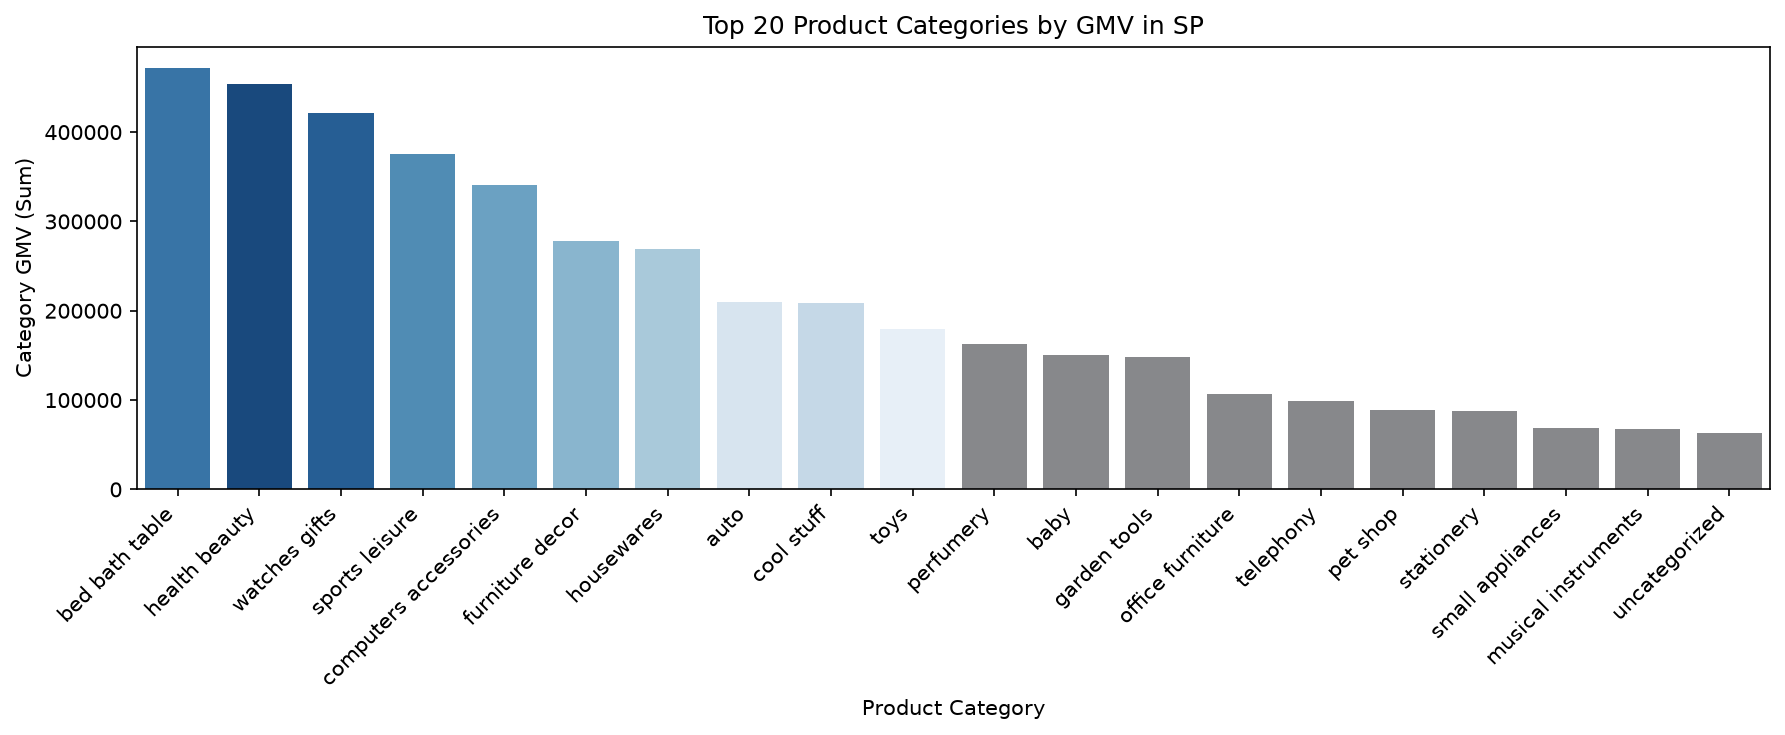

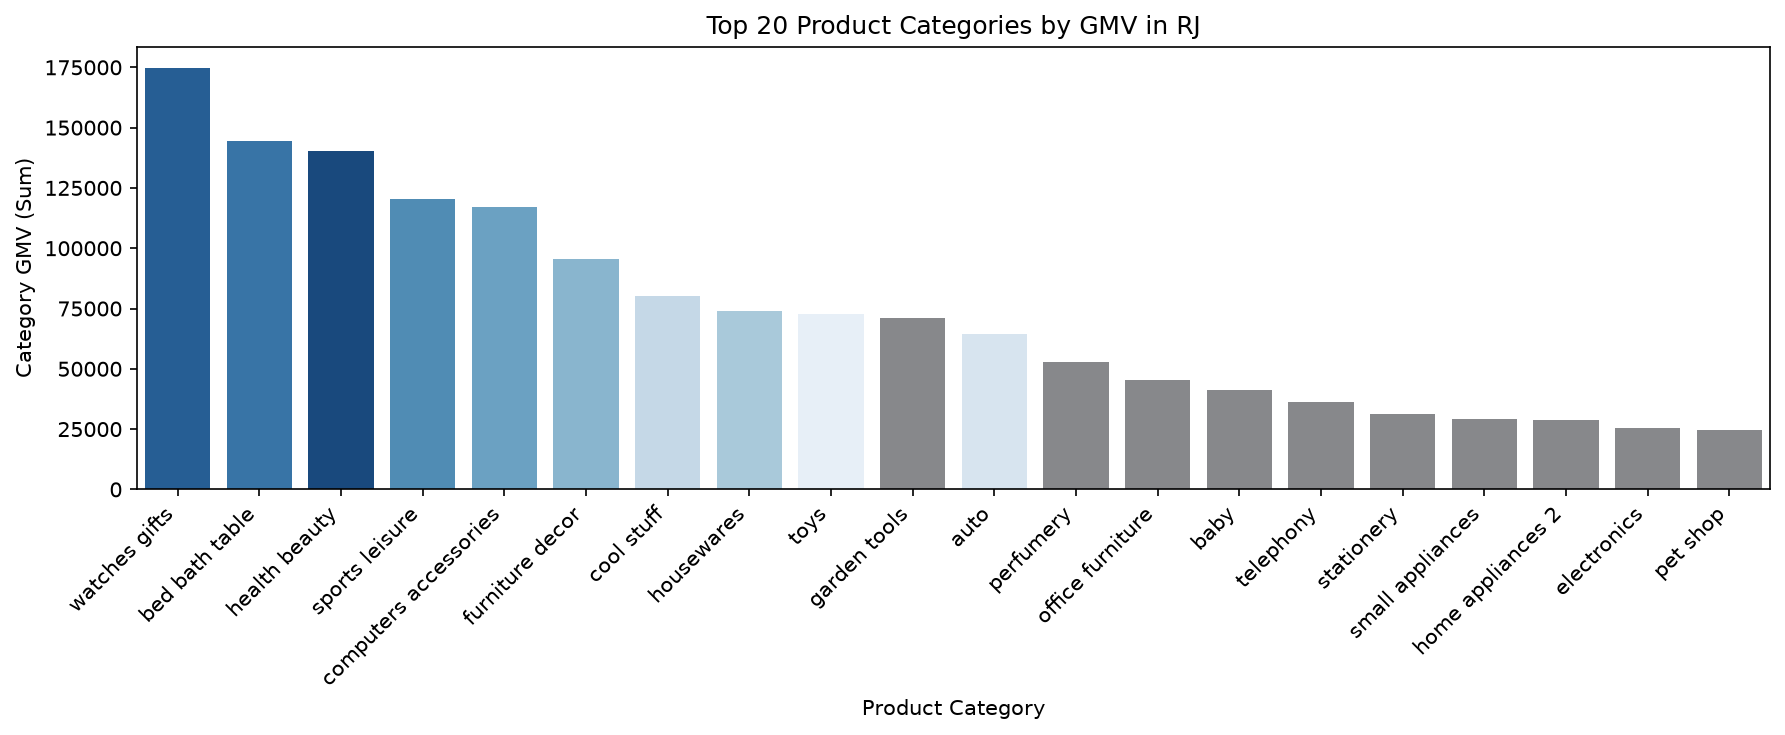

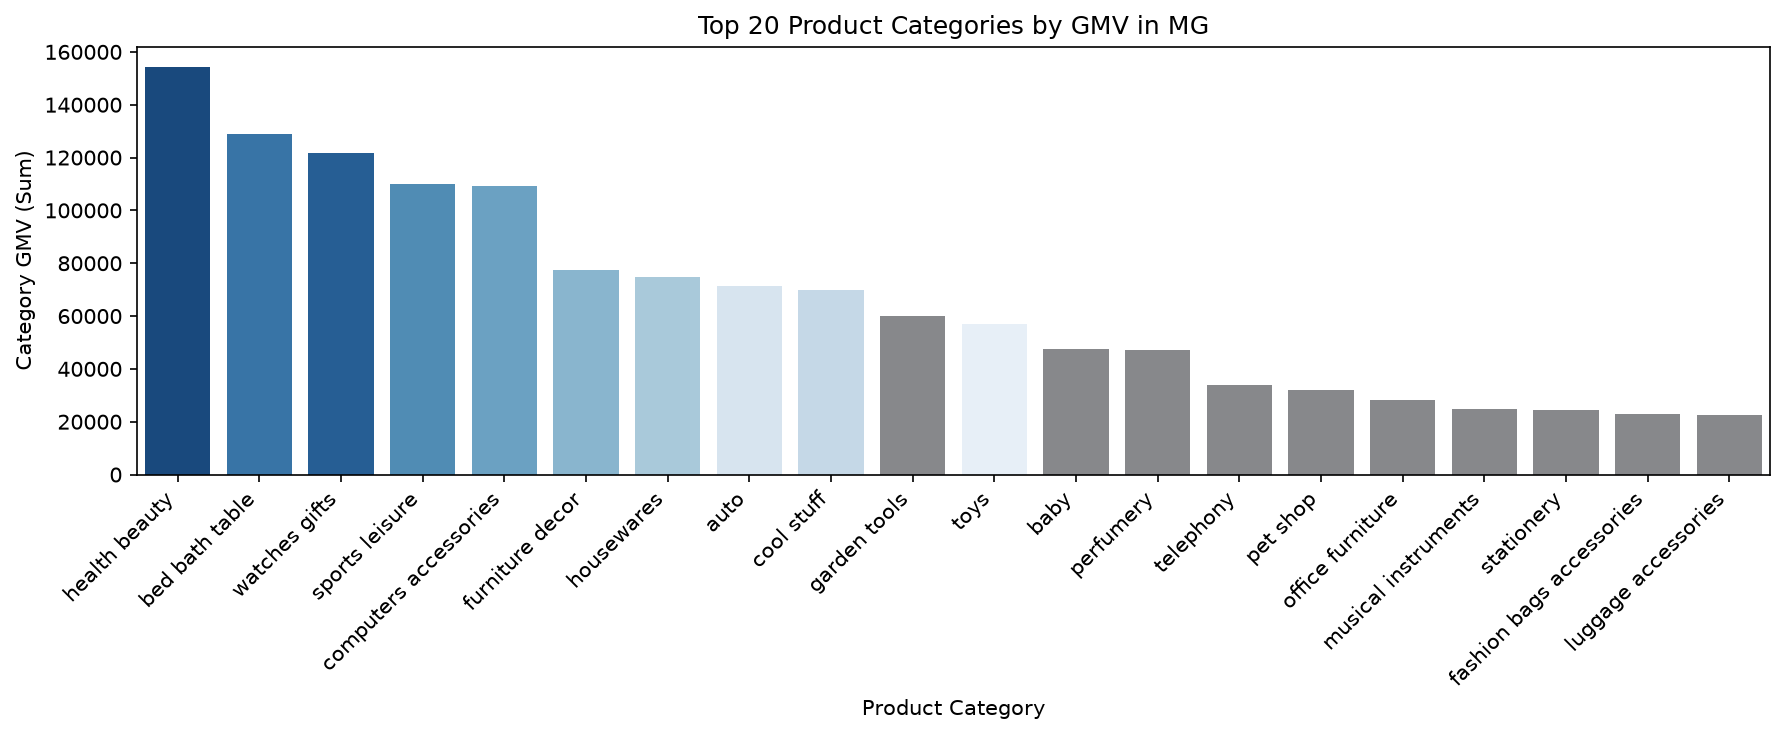

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# SP, RJ, MG の3州を個別に描画する
# 円グラフと同じカテゴリ配色を使って、見た目を統一する
selected_states = ["SP", "RJ", "MG"]

# 全体Top 10カテゴリのGMV順位に対応した青のグラデーション（上位ほど濃い青）
top10_categories = (
    df_category.groupby("product_category")["category_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
pie_color_map = dict(
    zip(top10_categories, sns.color_palette("Blues_r", n_colors=len(top10_categories)).as_hex())
)

for state in selected_states:
    df_state_data = df_category[
        df_category["customer_state"] == state
    ].copy()

    category_order = (
        df_state_data.groupby("product_category", as_index=False)
        .agg(category_gmv=("category_gmv", "sum"))
        .sort_values("category_gmv", ascending=False)
        .head(20)["product_category"]
        .tolist()
    )

    bar_data = df_state_data[
        df_state_data["product_category"].isin(category_order)
    ].copy()
    bar_data = (
        bar_data.groupby("product_category", as_index=False)
        .agg(category_gmv=("category_gmv", "sum"))
        .sort_values("category_gmv", ascending=False)
        .reset_index(drop=True)
    )
    bar_data["display_name"] = bar_data["product_category"].str.replace("_", " ")
    bar_data["color"] = bar_data["product_category"].apply(
        lambda x: pie_color_map.get(x, "#86888c")
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=bar_data,
        x="display_name",
        y="category_gmv",
        order=bar_data["display_name"].tolist(),
        hue="display_name",
        hue_order=bar_data["display_name"].tolist(),
        palette=bar_data["color"].tolist(),
        dodge=False,
        legend=False,
        errorbar=None,
    )
    plt.title(f"Top 20 Product Categories by GMV in {state}")
    plt.xlabel("Product Category")
    plt.ylabel("Category GMV (Sum)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

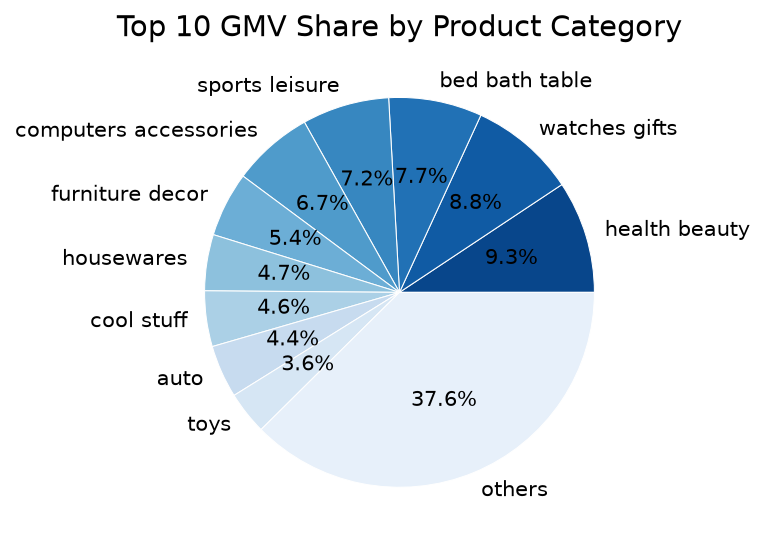

In [15]:
# 全体の product_category ごとの GMV シェアを円グラフで描画する
product_share = (
    df_category.groupby("product_category", as_index=False)
    .agg(category_gmv=("category_gmv", "sum"))
    .sort_values("category_gmv", ascending=False)
    .reset_index(drop=True)
)

n_top = 10
if len(product_share) > n_top:
    pie_values = product_share["category_gmv"].iloc[:n_top].tolist() + [
        product_share["category_gmv"].iloc[n_top:].sum()
    ]
    pie_labels = product_share["product_category"].iloc[:n_top].tolist() + ["others"]
else:
    pie_values = product_share["category_gmv"].tolist()
    pie_labels = product_share["product_category"].tolist()

# 全体のGMV順位を基準にカテゴリごとの色を固定する
base_colors = sns.color_palette("Blues_r", n_colors=len(pie_labels)).as_hex()
category_color_map = dict(zip(pie_labels, base_colors))
colors = [category_color_map[category] for category in pie_labels]
short_labels = [cat.replace("_", " ") for cat in pie_labels]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"aspect": "equal"})
ax.pie(
    pie_values,
    labels=short_labels,
    autopct="%1.1f%%",
    startangle=0,
    counterclock=True,
    labeldistance=1.1,
    textprops={"fontsize": 10},
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    colors=colors,
)
ax.set_title("Top 10 GMV Share by Product Category", fontsize=14)
plt.tight_layout()
plt.show()

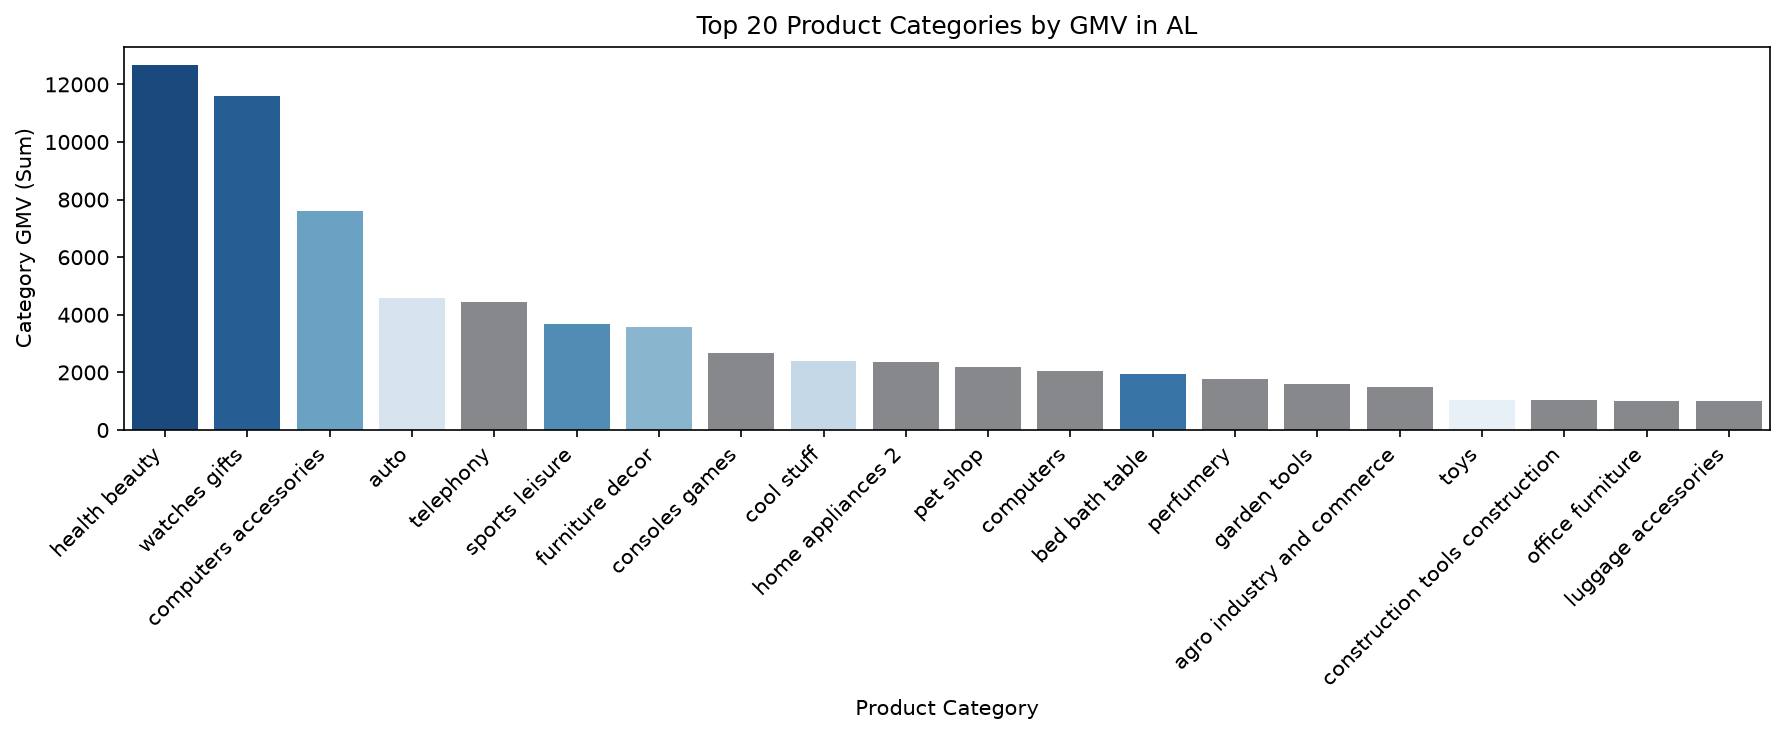

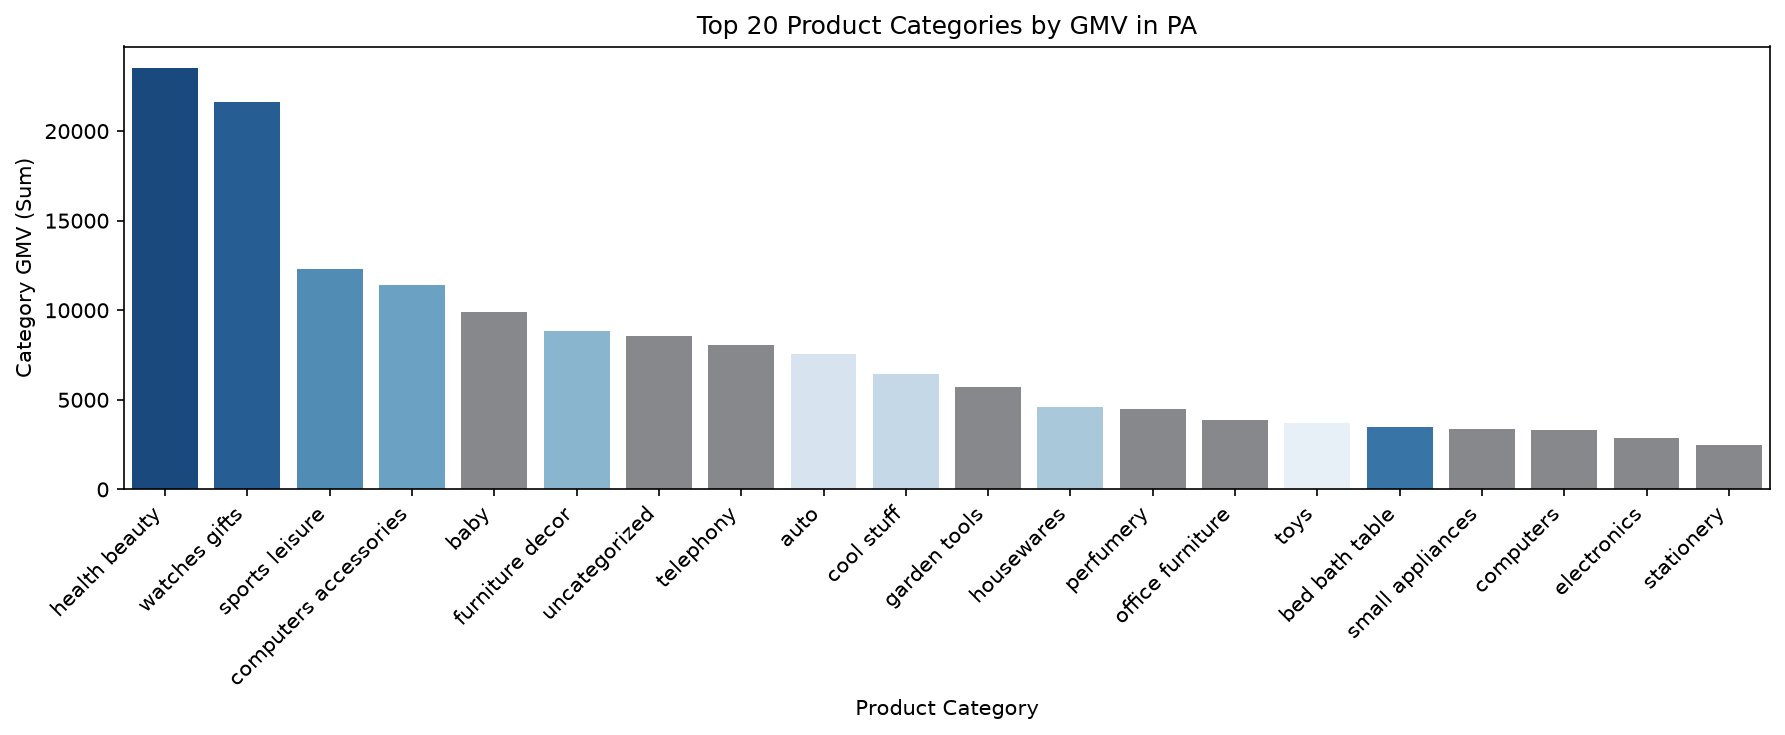

In [16]:
# AL, PA の各州で Top20 category の棒グラフを描画する
# 円グラフと同じカテゴリ配色を使って、見た目を統一する
selected_states = ["AL", "PA"]

# 全体Top 10カテゴリのGMV順位に対応した青のグラデーション（上位ほど濃い青）
top10_categories = (
    df_category.groupby("product_category")["category_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
pie_color_map = dict(
    zip(top10_categories, sns.color_palette("Blues_r", n_colors=len(top10_categories)).as_hex())
)

for state in selected_states:
    df_state_data = df_category[df_category["customer_state"] == state].copy()

    category_order = (
        df_state_data.groupby("product_category", as_index=False)
        .agg(category_gmv=("category_gmv", "sum"))
        .sort_values("category_gmv", ascending=False)
        .head(20)["product_category"]
        .tolist()
    )

    bar_data = df_state_data[
        df_state_data["product_category"].isin(category_order)
    ].copy()
    bar_data = (
        bar_data.groupby("product_category", as_index=False)
        .agg(category_gmv=("category_gmv", "sum"))
        .sort_values("category_gmv", ascending=False)
        .reset_index(drop=True)
    )
    bar_data["display_name"] = bar_data["product_category"].str.replace("_", " ")
    bar_data["color"] = bar_data["product_category"].apply(
        lambda x: pie_color_map.get(x, "#86888c")
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=bar_data,
        x="display_name",
        y="category_gmv",
        order=bar_data["display_name"].tolist(),
        hue="display_name",
        hue_order=bar_data["display_name"].tolist(),
        palette=bar_data["color"].tolist(),
        dodge=False,
        legend=False,
        errorbar=None,
    )
    plt.title(f"Top 20 Product Categories by GMV in {state}")
    plt.xlabel("Product Category")
    plt.ylabel("Category GMV (Sum)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [17]:
# 月×州の集計から、州ごとのユニークな注文数とGMVを作る
df_baseline = pd.read_csv("../data/sales_baseline_by_month_state.csv")

state_totals = (
    df_baseline
    .groupby("customer_state", as_index=False)
    .agg(
        state_orders=("order_count", "sum"),
        state_gmv=("gmv", "sum"),
    )
)

# 比較したい州とカテゴリを取り出す
target_states = ["SP", "AL", "PA"]
target_categories = ["bed_bath_table", "toys"]

category_comparison = df_category[
    df_category["customer_state"].isin(target_states)
    & df_category["product_category"].isin(target_categories)
].copy()

# 州全体の注文数・GMVを、カテゴリ別の行に付ける
category_comparison = category_comparison.merge(
    state_totals,
    on="customer_state",
    how="left",
)

# そのカテゴリを含む注文の割合と、州内GMVシェアを計算する
category_comparison["category_order_rate_pct"] = (
    category_comparison["category_order_count"]
    / category_comparison["state_orders"]
    * 100
)
category_comparison["category_gmv_share_pct"] = (
    category_comparison["category_gmv"]
    / category_comparison["state_gmv"]
    * 100
)

display(
    category_comparison[
        [
            "customer_state",
            "product_category",
            "state_orders",
            "category_order_count",
            "category_order_rate_pct",
            "category_gmv_share_pct",
        ]
    ]
    .sort_values(["product_category", "customer_state"])
    .round(2)
)

,customer_state,product_category,state_orders,category_order_count,category_order_rate_pct,category_gmv_share_pct
0,AL,bed_bath_table,397,18,4.53,2.45
3,PA,bed_bath_table,946,34,3.59,2.01
4,SP,bed_bath_table,40501,4347,10.73,9.32
1,AL,toys,397,12,3.02,1.34
2,PA,toys,946,27,2.85,2.14
5,SP,toys,40501,1577,3.89,3.55


### SP・RJ・MGのカテゴリ構成と平均注文額の比較

注文数とGMVが大きい3州を、平均注文額が高かったPB・APとも比較する。比較するカテゴリは、前の分析で差が目立ったものと、3州でGMVが大きい`bed_bath_table`を選んだ。州全体の注文数を分母として、カテゴリ購入割合と平均注文額への構成額を計算する。

- カテゴリ購入割合 = カテゴリを含む注文数 ÷ 州のユニークな注文数
- カテゴリ注文あたりGMV = カテゴリGMV ÷ カテゴリを含む注文数（注文全体の金額ではない）
- 平均注文額への構成額 = カテゴリGMV ÷ 州のユニークな注文数

これらは過去の購入構成を示す。施策による平均注文額やGMVの変化は示さない。


In [18]:
# 月×州の集計から、州全体のユニークな注文数・GMVを作る
# カテゴリ別注文数を足すと、複数カテゴリを買った注文が重複する
sales_baseline = pd.read_csv('../data/sales_baseline_by_month_state.csv')
state_totals = (
    sales_baseline.groupby('customer_state', as_index=False)
    .agg(state_orders=('order_count', 'sum'), state_gmv=('gmv', 'sum'))
)
state_totals['average_order_value'] = (
    state_totals['state_gmv'] / state_totals['state_orders']
)

major_states = ['SP', 'RJ', 'MG']
reference_states = ['PB', 'AP']
comparison_states = major_states + reference_states

display(
    state_totals.loc[
        state_totals['customer_state'].isin(comparison_states),
        ['customer_state', 'state_orders', 'state_gmv', 'average_order_value'],
    ].sort_values('state_gmv', ascending=False).round(2)
)


,customer_state,state_orders,state_gmv,average_order_value
25,SP,40501,5067633.16,125.12
18,RJ,12350,1759651.13,142.48
10,MG,11354,1552481.83,136.73
14,PB,517,112586.82,217.77
3,AP,67,13374.81,199.62


In [19]:
# これまで差が目立ったカテゴリと、3州でGMVが大きいカテゴリを比較する
focus_categories = [
    'bed_bath_table',
    'health_beauty',
    'watches_gifts',
    'computers_accessories',
    'computers',
    'auto',
]

major_category_comparison = (
    df_category.loc[
        df_category['customer_state'].isin(comparison_states)
        & df_category['product_category'].isin(focus_categories)
    ]
    .merge(state_totals, on='customer_state', how='left')
)
major_category_comparison['category_order_rate_pct'] = (
    major_category_comparison['category_order_count']
    / major_category_comparison['state_orders'] * 100
)
major_category_comparison['category_gmv_per_category_order'] = (
    major_category_comparison['category_gmv']
    / major_category_comparison['category_order_count']
)
major_category_comparison['aov_part'] = (
    major_category_comparison['category_gmv']
    / major_category_comparison['state_orders']
)

# 同じカテゴリについて5州を並べ、割合だけでなく注文数も確認する
major_category_comparison['customer_state'] = pd.Categorical(
    major_category_comparison['customer_state'],
    categories=comparison_states,
    ordered=True,
)
display(
    major_category_comparison.sort_values(
        ['product_category', 'customer_state']
    )[
        ['product_category', 'customer_state', 'state_orders',
         'category_order_count', 'category_order_rate_pct',
         'category_gmv_per_category_order', 'aov_part']
    ].round(2)
)


,product_category,customer_state,state_orders,category_order_count,category_order_rate_pct,category_gmv_per_category_order,aov_part
28,auto,SP,40501,1585,3.91,132.08,5.17
22,auto,RJ,12350,402,3.26,160.20,5.21
10,auto,MG,11354,461,4.06,155.13,6.30
16,auto,PB,517,22,4.26,188.24,8.01
4,auto,AP,67,3,4.48,405.46,18.16
24,bed_bath_table,SP,40501,4347,10.73,108.64,11.66
19,bed_bath_table,RJ,12350,1357,10.99,106.30,11.68
7,bed_bath_table,MG,11354,1120,9.86,114.96,11.34
17,bed_bath_table,PB,517,29,5.61,120.50,6.76
5,bed_bath_table,AP,67,3,4.48,223.17,9.99


### SP・RJ・MGそれぞれのカテゴリGMV構成

全体のカテゴリ円グラフと同じ形式で、各州のカテゴリGMV上位10件を表示し、残りを`others`にまとめる。各円グラフの分母は**その州のGMV**。円グラフ同士の大きさは州のGMV規模を表さないため、上の州別GMV表とあわせて読む。


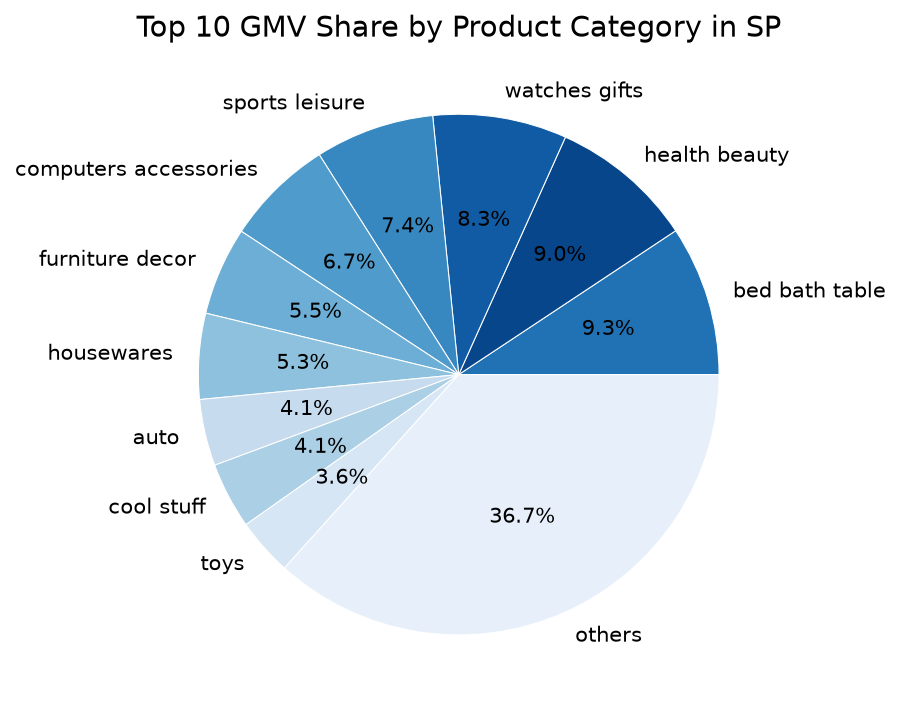

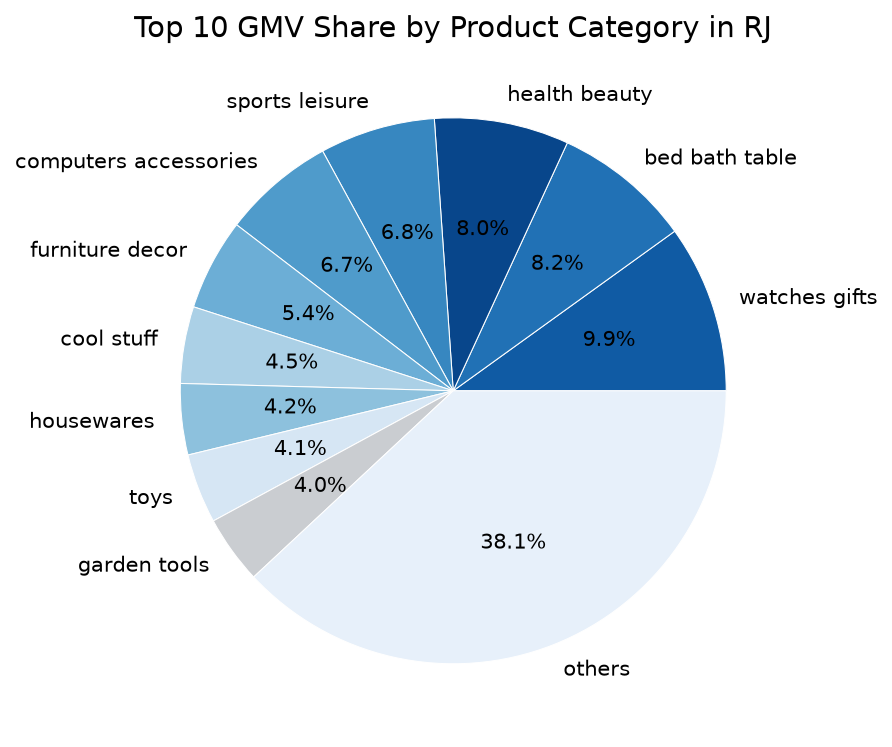

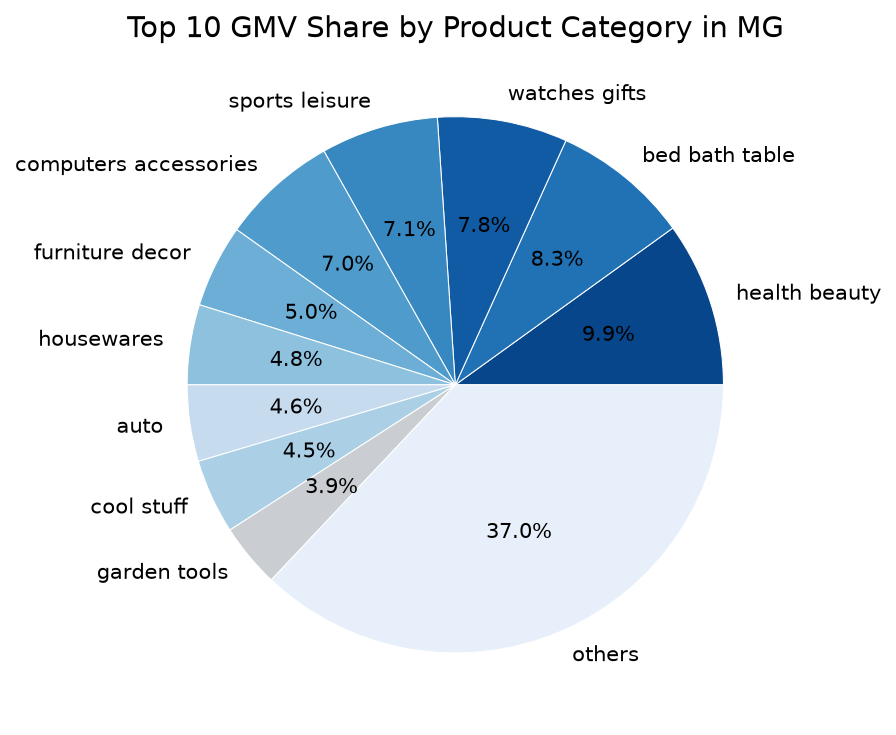

In [20]:
# 全体カテゴリ図のカテゴリ別カラーを使って、州ごとの構成比を描く
for state in major_states:
    state_categories = (
        df_category.loc[df_category['customer_state'] == state]
        .sort_values('category_gmv', ascending=False)
        .reset_index(drop=True)
    )
    top10 = state_categories.head(10)
    other_gmv = state_categories['category_gmv'].iloc[10:].sum()
    pie_values = top10['category_gmv'].tolist() + [other_gmv]
    pie_labels = top10['product_category'].tolist() + ['others']
    short_labels = [name.replace('_', ' ') for name in pie_labels]
    # 全体Top 10のカテゴリとothersは全体図と同じ色にする。
    # 全体Top 10外のカテゴリはグレーで表示する。
    colors = [
        category_color_map.get(category, '#cacdd1')
        for category in pie_labels
    ]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'aspect': 'equal'})
    ax.pie(
        pie_values,
        labels=short_labels,
        autopct='%1.1f%%',
        startangle=0,
        counterclock=True,
        labeldistance=1.1,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
        colors=colors,
    )
    ax.set_title(f'Top 10 GMV Share by Product Category in {state}', fontsize=14)
    plt.tight_layout()
    fig.savefig(
        f'../images/Top10_GMV_Share_by_Product_Category_in_{state}.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()


### 次に読むこと

- SP・RJ・MGで同じカテゴリでも購入割合とカテゴリ注文あたりGMVは異なるか。
- 上位カテゴリの件数は十分か。PB・APの少数注文を3州にそのまま当てはめない。
- 月別の安定性、商品・販売者の構成、販促費と利益を確認するまでは、客単価向上策の効果を断定しない。
